# Football schedules, lottery demand, and Sauvie Island harvest

This notebook compares Oregon Ducks, Oregon State Beavers, and Seattle Seahawks game dates with Sauvie Island first-choice reservation applications and harvest records for the 2021-22 through 2025-26 hunting seasons.

The controlled comparison includes **Saturday games and Saturday non-game hunt dates for both Oregon schools**, and **Sunday games and Sunday non-game hunt dates for Seattle**. Other game weekdays are excluded. Controls come from the same hunting season, but the results remain observational and are not causal.

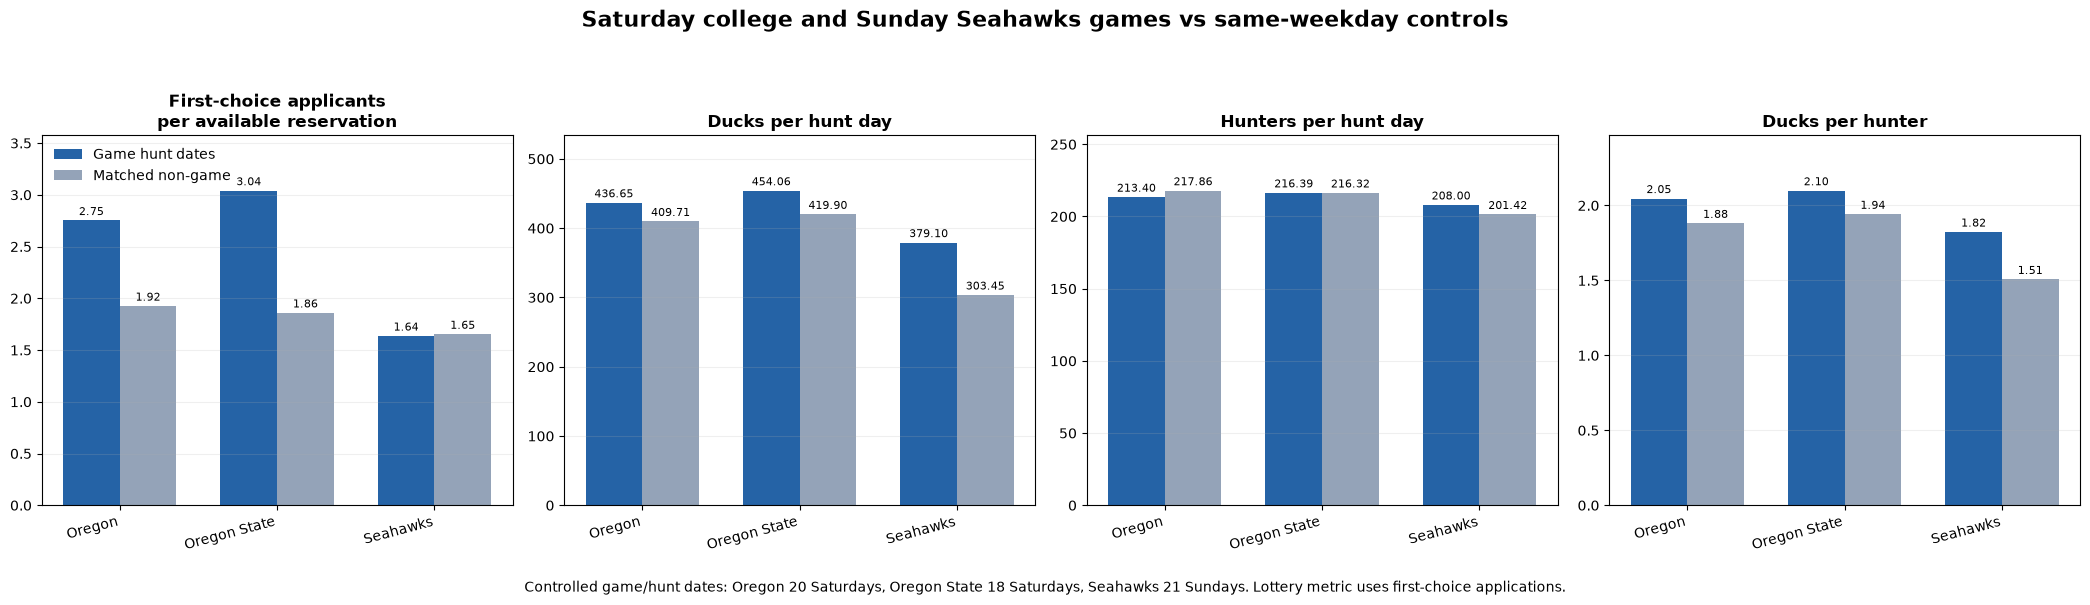

In [1]:
# Load one row per hunt date and build weekday-matched comparison groups.
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "processed" / "duckit_oregon.duckdb"
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
con = duckdb.connect(str(DB_PATH), read_only=True)
hunt_days = con.sql("SELECT * FROM hunt_day_sports_comparison").df()

teams = [
    ("Oregon", "oregon_game", "Saturday"),
    ("Oregon State", "oregon_state_game", "Saturday"),
    ("Seahawks", "seahawks_game", "Sunday"),
]
total_columns = [
    "first_choice_applicants",
    "reservations_available",
    "ducks",
    "hunters",
]
comparison_rows = []

for team, flag, controlled_weekday in teams:
    game_days = hunt_days.loc[
        hunt_days[flag] & (hunt_days["weekday"] == controlled_weekday)
    ].copy()
    actual = game_days[total_columns].sum().astype(float)
    baseline = pd.Series(0.0, index=total_columns)
    control_indexes = set()

    # Match Saturday college games only to non-game Saturdays, and Sunday
    # Seahawks games only to non-game Sundays, within each hunting season.
    for season, games in game_days.groupby("season"):
        controls = hunt_days.loc[
            (hunt_days["season"] == season)
            & (hunt_days["weekday"] == controlled_weekday)
            & (~hunt_days[flag])
        ]
        if controls.empty:
            raise ValueError(
                f"No {controlled_weekday} controls for {team}, {season}"
            )
        baseline += controls[total_columns].mean() * len(games)
        control_indexes.update(controls.index)

    for label, totals in [("Game hunt dates", actual), ("Matched non-game", baseline)]:
        comparison_rows.append(
            {
                "team": team,
                "comparison": label,
                "game_hunt_dates": len(game_days),
                "control_pool_dates": len(control_indexes),
                "applicants_per_reservation": (
                    totals["first_choice_applicants"]
                    / totals["reservations_available"]
                ),
                "ducks_per_hunt_day": totals["ducks"] / len(game_days),
                "hunters_per_hunt_day": totals["hunters"] / len(game_days),
                "ducks_per_hunter": totals["ducks"] / totals["hunters"],
            }
        )

comparison = pd.DataFrame(comparison_rows)
metrics = [
    ("applicants_per_reservation", "First-choice applicants\nper available reservation"),
    ("ducks_per_hunt_day", "Ducks per hunt day"),
    ("hunters_per_hunt_day", "Hunters per hunt day"),
    ("ducks_per_hunter", "Ducks per hunter"),
]

fig, axes = plt.subplots(1, 4, figsize=(21, 6))
x = np.arange(len(teams))
width = 0.36
for axis, (metric, title) in zip(axes, metrics):
    for offset, label, color in [
        (-width / 2, "Game hunt dates", "#2563a6"),
        (width / 2, "Matched non-game", "#94a3b8"),
    ]:
        values = (
            comparison.loc[comparison["comparison"] == label]
            .set_index("team")
            .loc[[team[0] for team in teams], metric]
        )
        bars = axis.bar(x + offset, values, width, label=label, color=color)
        axis.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
    axis.set_title(title, fontweight="bold")
    axis.set_xticks(x, [team[0] for team in teams], rotation=15, ha="right")
    axis.grid(axis="y", alpha=0.2)
    axis.set_ylim(0, axis.get_ylim()[1] * 1.12)

axes[0].legend(frameon=False, loc="upper left")
fig.suptitle(
    "Saturday college and Sunday Seahawks games vs same-weekday controls",
    fontsize=16,
    fontweight="bold",
)
fig.text(
    0.5,
    0.01,
    "Controlled game/hunt dates: Oregon 20 Saturdays, Oregon State 18 Saturdays, "
    "Seahawks 21 Sundays. Lottery metric uses first-choice applications.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=[0, 0.05, 1, 0.93])
fig.savefig(ARTIFACTS / "sports-schedule-comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Initial finding

Using only Saturday comparisons for the Oregon schools and Sunday comparisons for Seattle:

- **Oregon Saturday games:** reservation demand was 2.75 versus 1.92 applicants per available reservation; harvest was 2.05 versus 1.88 ducks per hunter.
- **Oregon State Saturday games:** demand was 3.04 versus 1.86; harvest was 2.10 versus 1.94 ducks per hunter.
- **Seahawks Sunday games:** demand was essentially unchanged at 1.64 versus 1.65, while harvest was 1.82 versus 1.51 ducks per hunter.

College Saturday game dates therefore coincide with higher application demand in this sample. Seahawks Sunday games show no meaningful demand difference. All three coincide with higher harvest efficiency, but that does **not** mean football improves hunting: week within season, weather, migration, and the small controlled samples remain possible explanations.

In [2]:
display_columns = [
    "team",
    "comparison",
    "game_hunt_dates",
    "control_pool_dates",
    "applicants_per_reservation",
    "ducks_per_hunt_day",
    "hunters_per_hunt_day",
    "ducks_per_hunter",
]
comparison[display_columns].round(2)

,team,comparison,game_hunt_dates,control_pool_dates,applicants_per_reservation,ducks_per_hunt_day,hunters_per_hunt_day,ducks_per_hunter
0,Oregon,Game hunt dates,20,25,2.75,436.65,213.40,2.05
1,Oregon,Matched non-game,20,25,1.92,409.71,217.86,1.88
2,Oregon State,Game hunt dates,18,27,3.04,454.06,216.39,2.10
3,Oregon State,Matched non-game,18,27,1.86,419.90,216.32,1.94
4,Seahawks,Game hunt dates,21,14,1.64,379.10,208.00,1.82
5,Seahawks,Matched non-game,21,14,1.65,303.45,201.42,1.51


## Schedule coverage and controlled overlaps

The database includes regular season, conference championship, bowl/playoff, and NFL postseason games. Kickoff timestamps are converted to Pacific time before date matching; NFL preseason is excluded. The controlled analysis below retains only Saturday college and Sunday Seahawks overlaps.

In [3]:
coverage = con.sql("""
    SELECT team, football_season, COUNT(*) AS games
    FROM football_game
    GROUP BY team, football_season
    ORDER BY team, football_season
""").df()

overlaps = con.sql("""
    SELECT
        team,
        COUNT(*) AS controlled_game_hunt_dates,
        MIN(hunt_date) AS first_overlap,
        MAX(hunt_date) AS last_overlap
    FROM sports_on_hunt_date
    WHERE
        (team IN ('Oregon Ducks', 'Oregon State Beavers')
            AND STRFTIME(hunt_date, '%A') = 'Saturday')
        OR (team = 'Seattle Seahawks'
            AND STRFTIME(hunt_date, '%A') = 'Sunday')
    GROUP BY team
    ORDER BY team
""").df()

coverage.pivot(index="football_season", columns="team", values="games"), overlaps

(team             Oregon Ducks  Oregon State Beavers  Seattle Seahawks
 football_season                                                      
 2021                       14                    13                17
 2022                       13                    13                18
 2023                       14                    13                17
 2024                       14                    12                17
 2025                       15                    12                20,
                    team  controlled_game_hunt_dates first_overlap last_overlap
 0          Oregon Ducks                          20    2021-10-30   2025-11-29
 1  Oregon State Beavers                          18    2021-10-30   2025-11-29
 2      Seattle Seahawks                          21    2021-11-14   2026-01-25)